In [1]:
!pip install lightly
!pip install torch-optimizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.6 MB/s eta 0:00:00


# Import Libraries 

In [2]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import PIL
from PIL import Image, ImageOps
from PIL.Image import Image

from tabulate import tabulate
from typing import Dict, List, Optional, Tuple, Union

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from torch.optim import AdamW
from torch.optim import SGD
from torch_optimizer import LARS
from torch.optim import lr_scheduler
from torch.optim.lr_scheduler import CosineAnnealingLR

from lightly.loss import NegativeCosineSimilarity
from lightly.models.modules import SimSiamPredictionHead, SimSiamProjectionHead
from lightly.transforms import SimSiamTransform

import torchvision
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from torchvision import transforms as T 

from torchinfo import summary
from tqdm import tqdm, notebook

from lightly.models.utils import deactivate_requires_grad, update_momentum
from lightly.utils.scheduler import cosine_schedule
from lightly.transforms.torchvision_v2_compatibility import (
    torchvision_transforms as T,
)
from lightly.transforms.utils import IMAGENET_NORMALIZE

# Configuration

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


# Variables

In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

data_dir = "/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer"
checkpoint_path = "/kaggle/working/simsiam_checkpoint.pth"
loss_file = "/kaggle/working/simsiam_loss.csv"

training_batch = 32
start_epoch = 0
total_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and Split Dataset

In [5]:
def load_split(split_dir, selected_classes=None):
    file_paths, labels = [], []
    for class_name in os.listdir(split_dir):
        if selected_classes and class_name not in selected_classes:
            continue  
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            for image_name in os.listdir(class_dir):
                file_paths.append(os.path.join(class_dir, image_name))
                labels.append(class_name)
    return pd.DataFrame({"file_path": file_paths, "label": labels})

data = load_split(os.path.join(data_dir, "Brain Cancer"), selected_classes=["brain_glioma", "brain_menin", "brain_tumor"])

In [6]:
# Take samples for faster training 
data = data.groupby("label").sample(n=200, random_state=42).reset_index(drop=True)
print(len(data))

600


In [7]:
train_dataframe, test_dataframe = train_test_split(
    data, 
    test_size=0.20, 
    stratify=data['label'], 
    random_state=42
)

print("Train set class distribution:")
print(train_dataframe['label'].value_counts())
print()

print("Test set class distribution:")
print(test_dataframe['label'].value_counts())

Train set class distribution:
label
brain_tumor     160
brain_glioma    160
brain_menin     160
Name: count, dtype: int64

Test set class distribution:
label
brain_glioma    40
brain_menin     40
brain_tumor     40
Name: count, dtype: int64


# Dataset Class, Data Transform and Dataloader

In [8]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, is_lb=False):
        self.file_paths = dataframe["file_path"].values
        self.transform = transform
        self.is_lb = is_lb

        if self.is_lb:
            if "label" not in dataframe.columns:
                raise ValueError("DataFrame must contain 'label' column for supervised tasks.")
            self.labels = dataframe["label"].values
            self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(set(self.labels)))}
            self.labels = np.array([self.class_to_idx[lbl] for lbl in self.labels])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):
        image_path = self.file_paths[index]
        image = PIL.Image.open(image_path).convert("RGB")

        if self.is_lb:
            label = self.labels[index]
            if self.transform:
                image = self.transform(image)
            return image, label
        else:
            if self.transform:
                x0, x1 = self.transform(image)
                return x0, x1
            else:
                raise ValueError("Transform must be provided for unsupervised learning.")

In [9]:
simsiam_transform = SimSiamTransform(
    input_size=224, 
    normalize=IMAGENET_NORMALIZE
)

training_dataset = ImageDataset(
    train_dataframe,
    transform=simsiam_transform,
    is_lb=False
)

dataloader = DataLoader(
    training_dataset, 
    batch_size=training_batch, 
    shuffle=True, 
    drop_last=True, 
    num_workers=2
)

# Self Supervised Model (SimSiam)

In [10]:
class SimSiam(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.projection_head = SimSiamProjectionHead(2048, 512, 128)
        self.prediction_head = SimSiamPredictionHead(128, 64, 128)

    def forward(self, x):
        f = self.backbone(x)
        f = f.mean([2,3])
        z = self.projection_head(f)
        p = self.prediction_head(z)
        return z.detach(), p


resnet = torchvision.models.resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V1
)
backbone = nn.Sequential(*list(resnet.children())[:-2])
model = SimSiam(backbone)
model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


SimSiam(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64,

# Model Training

In [11]:
criterion = NegativeCosineSimilarity()
optimizer = SGD(
    model.parameters(),
    lr=0.05,
    momentum=0.9,
    weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs)

In [12]:
loss_history = []

with open(loss_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss'])

print("Starting Training")
total_start_time = time.time() 

for epoch in range(start_epoch, total_epochs):
    start_time = time.time()
    total_loss = 0
    for batch in dataloader:
        x0, x1 = batch
        x0 = x0.to(device)
        x1 = x1.to(device)
        z0, p0 = model(x0)
        z1, p1 = model(x1)
        loss = 0.5 * (criterion(z0, p1) + criterion(z1, p0))
        total_loss += loss.detach()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    avg_loss = total_loss / len(dataloader)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    loss_history.append(avg_loss.item())
    
    with open(loss_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, avg_loss.item()])
    
    end_time = time.time()  
    epoch_duration = end_time - start_time  
    minutes = int(epoch_duration // 60)
    seconds = int(epoch_duration % 60)
    
    print(f"epoch: {epoch+1:>02}, loss: {avg_loss:.5f}, lr: {current_lr:.6f}, time: {minutes}m {seconds}s")

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }, checkpoint_path)

total_end_time = time.time()
total_training_time = total_end_time - total_start_time

hours = int(total_training_time // 3600)
minutes = int((total_training_time % 3600) // 60)
seconds = int(total_training_time % 60)

print("Training completed!")
print(f"Total training time: {hours}h {minutes}m {seconds}s")

Starting Training
epoch: 01, loss: -0.04573, lr: 0.049988, time: 0m 7s
epoch: 02, loss: -0.25535, lr: 0.049951, time: 0m 5s
epoch: 03, loss: -0.60810, lr: 0.049889, time: 0m 5s
epoch: 04, loss: -0.73625, lr: 0.049803, time: 0m 5s
epoch: 05, loss: -0.78740, lr: 0.049692, time: 0m 5s
epoch: 06, loss: -0.81022, lr: 0.049557, time: 0m 5s
epoch: 07, loss: -0.80161, lr: 0.049398, time: 0m 5s
epoch: 08, loss: -0.81878, lr: 0.049215, time: 0m 5s
epoch: 09, loss: -0.82122, lr: 0.049007, time: 0m 5s
epoch: 10, loss: -0.84150, lr: 0.048776, time: 0m 5s
epoch: 11, loss: -0.86557, lr: 0.048522, time: 0m 5s
epoch: 12, loss: -0.85439, lr: 0.048244, time: 0m 5s
epoch: 13, loss: -0.87261, lr: 0.047944, time: 0m 5s
epoch: 14, loss: -0.88363, lr: 0.047621, time: 0m 5s
epoch: 15, loss: -0.89709, lr: 0.047275, time: 0m 5s
epoch: 16, loss: -0.89945, lr: 0.046908, time: 0m 5s
epoch: 17, loss: -0.89654, lr: 0.046519, time: 0m 5s
epoch: 18, loss: -0.90538, lr: 0.046108, time: 0m 5s
epoch: 19, loss: -0.90288, l

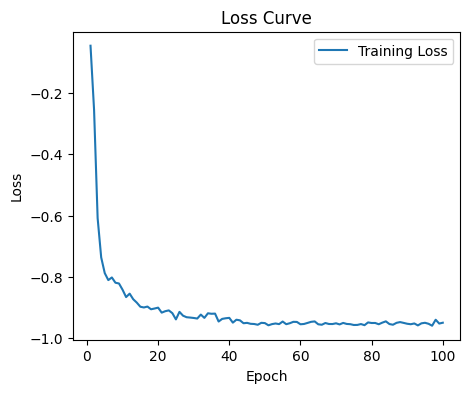

In [13]:
loss_df = pd.read_csv(loss_file)

plt.figure(figsize=(5,4))
plt.plot(loss_df['epoch'], loss_df['loss'], label="Training Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(False) 
plt.legend()
plt.show()

# Extract Embeddings

In [14]:
model.eval()

def extract_embeddings(model, dataloader, device):
    embeddings = []
    labels_list = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:  
            images = images.to(device)
            features = model.backbone(images).mean([2, 3])
            embeddings.append(features.cpu())
            labels_list.append(labels.cpu())  

    embeddings = torch.cat(embeddings, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

In [15]:
embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_embedding = ImageDataset(
    train_dataframe, 
    transform=embedding_transform, 
    is_lb=True
)

train_embedding_loader = DataLoader(
    train_embedding, 
    batch_size=training_batch, 
    shuffle=False
)

test_embedding = ImageDataset(
    test_dataframe,
    transform=embedding_transform,
    is_lb=True
)

test_embedding_loader = DataLoader(
    test_embedding,
    batch_size=training_batch,
    shuffle=False
)

In [16]:
train_embeddings, train_labels = extract_embeddings(model, train_embedding_loader, device)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Train labels shape: {train_labels.shape}")

test_embeddings, test_labels = extract_embeddings(model, test_embedding_loader, device)

print(f"\nTest embeddings shape: {test_embeddings.shape}")
print(f"Test labels shape: {test_labels.shape}")

Train embeddings shape: (480, 2048)
Train labels shape: (480,)

Test embeddings shape: (120, 2048)
Test labels shape: (120,)


# Cluster Plots 

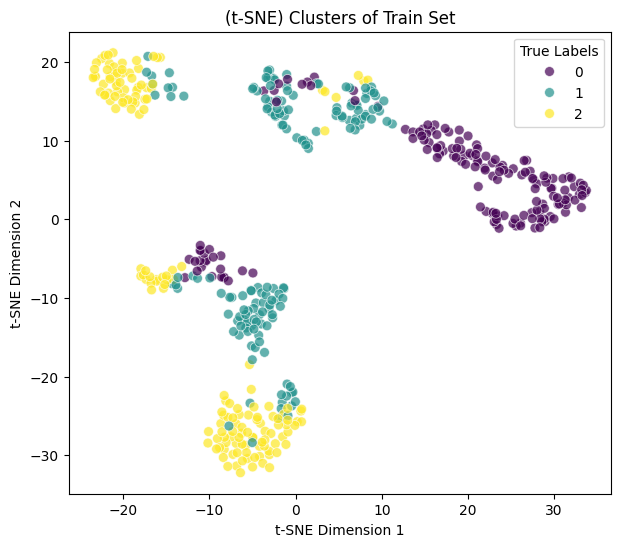

In [17]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(train_embeddings)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=embeddings_2d[:, 0], 
    y=embeddings_2d[:, 1],
    hue=train_labels,  
    palette='viridis',
    alpha=0.7,
    s=50
)

plt.title('(t-SNE) Clusters of Train Set')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='True Labels')
plt.grid(False)
plt.show()

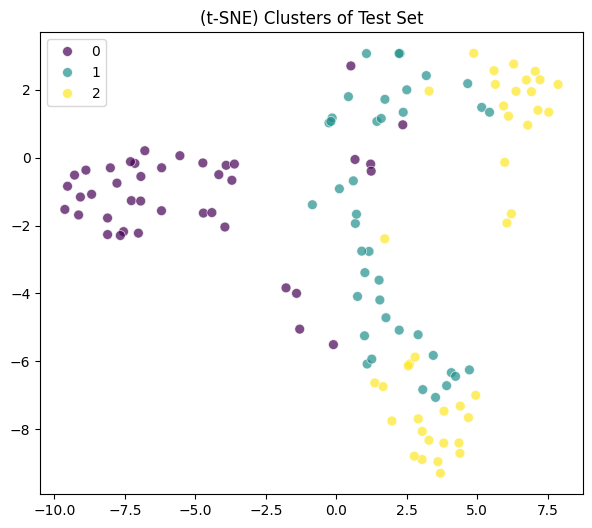

In [18]:
tsne_test = TSNE(n_components=2, random_state=42, perplexity=30)
test_embeddings_2d = tsne_test.fit_transform(test_embeddings)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=test_embeddings_2d[:, 0],
    y=test_embeddings_2d[:, 1],
    hue=test_labels,
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title("(t-SNE) Clusters of Test Set")
plt.grid(False)
plt.show()

# Evaluation

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("=" * 30)
print("Linear Classifier Evaluation")
print("=" * 30)

scaler = StandardScaler()
train_embeddings_scaled = scaler.fit_transform(train_embeddings)
test_embeddings_scaled  = scaler.transform(test_embeddings)

clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs',
    multi_class='auto'
)
clf.fit(train_embeddings_scaled, train_labels)

test_preds  = clf.predict(test_embeddings_scaled)
test_acc  = accuracy_score(test_labels,  test_preds)
print(f"Test  Accuracy : {test_acc  * 100:.2f}%")

Linear Classifier Evaluation


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test  Accuracy : 85.00%


In [20]:
print("Classification Report (Test Set):")
print(classification_report(test_labels, test_preds))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        40
           1       0.75      0.82      0.79        40
           2       0.87      0.82      0.85        40

    accuracy                           0.85       120
   macro avg       0.86      0.85      0.85       120
weighted avg       0.86      0.85      0.85       120



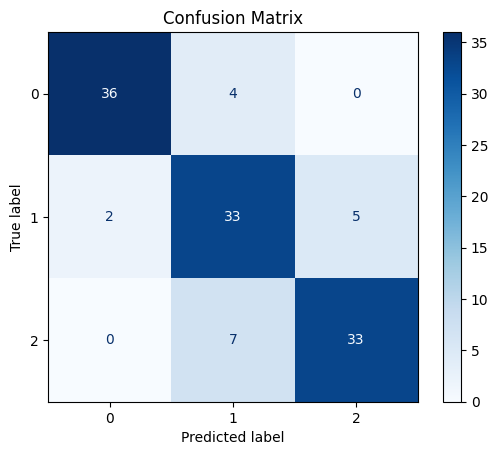

In [21]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()